# AutoEIT — Automated Elicited Imitation Task Transcription

**Goal:** Automatically transcribe non-native Spanish speaker responses from EIT audio recordings using a model-agnostic, Mac-native optimized ASR pipeline.

## Pipeline Architecture
```
MP3 → Preprocessing → Segmentation → ASR → Post-Processing → Excel Output
       │                │               │          │
  Normalize audio   30 segments     Spanish-tuned  Preserve learner errors
  Noise reduction   per file        multi-pass     Fix ASR artifacts
  Skip intro        tone detection  prompt-guided  Format disfluencies
```

## Key Design Principles
- **Model-agnostic:** Switch between whisper.cpp, MLX-Whisper, faster-whisper, or custom fine-tuned models via config
- **Mac-native:** Metal acceleration via whisper.cpp/MLX on Apple Silicon
- **Experiment tracking:** Every run is logged with config, results, and metrics for iterative improvement
- **Disfluency preservation:** Transcribe EXACT participant production — never correct grammar/vocabulary errors

---
## 1. Environment Setup

In [1]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

# Ensure project root is on path
PROJECT_ROOT = os.path.abspath('.')
SRC_DIR = os.path.join(PROJECT_ROOT, 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version}")

# Check for Apple Silicon
import platform
print(f"Platform: {platform.machine()} — {platform.system()} {platform.release()}")

Project root: /Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai
Python: 3.9.6 (default, Dec  2 2025, 07:27:58) 
[Clang 17.0.0 (clang-1700.6.3.2)]
Platform: arm64 — Darwin 25.0.0


In [2]:
# Core imports
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib
import json
from pathlib import Path
from IPython.display import Audio, display, HTML
import openpyxl

# AutoEIT imports
from autoeit.config import PipelineConfig, AudioFileConfig, TARGET_SENTENCES
from autoeit.experiment_logger import ExperimentLogger, ParticipantResult, TranscriptionResult
from autoeit.preprocessing import preprocess_audio, normalise_peak, reduce_noise, compute_rms
from autoeit.segmentation import segment_audio, detect_tones, detect_non_silent
from autoeit.postprocessing import postprocess_transcription
from autoeit.asr import create_asr_backend
from autoeit.asr.base import ASRResult
from autoeit.evaluation import evaluate_participant, evaluate_all
from autoeit.output import write_results_to_excel, write_detailed_results
from autoeit.pipeline import AutoEITPipeline

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams['figure.figsize'] = (14, 4)
matplotlib.rcParams['figure.dpi'] = 100

print("All imports successful ✓")

All imports successful ✓


---
## 2. Configuration

All pipeline parameters are centralised in a single config. Swap models by changing one line.

In [23]:
# Load configuration (choose one)
# Option A: Default config (MLX-Whisper small — recommended for Apple Silicon)
config = PipelineConfig.from_yaml('configs/default.yaml')

# Option B: whisper.cpp config (Metal accelerated)
# config = PipelineConfig.from_yaml('configs/whisper_cpp.yaml')

# Option C: Build config programmatically
# config = PipelineConfig()
# config.asr.backend = 'mlx_whisper'
# config.asr.model_size = 'small'

# -- Quick overrides --
config.experiment_name = 'large_v3_benchmark'
config.experiment_description = 'Whisper large-v3 performance benchmark vs small baseline'
config.tags = ['notebook', 'large-v3', 'benchmark']

# Switch to Whisper large-v3
config.asr.model_size = 'large'
config.asr.mlx_model_repo = 'mlx-community/whisper-large-v3-mlx'

# Resolve paths
resolved = config.resolve_paths(PROJECT_ROOT)

print(f"Backend:    {config.asr.backend}")
print(f"Model:      {config.asr.model_size}")
print(f"MLX repo:   {config.asr.mlx_model_repo}")
print(f"Language:   {config.asr.language}")
print(f"Audio dir:  {resolved.audio_dir}")
print(f"\nAudio files:")
for af in config.audio_files:
    print(f"  {af.participant_id} ({af.eit_version}) — skip {af.skip_seconds}s")

Backend:    mlx_whisper
Model:      large
MLX repo:   mlx-community/whisper-large-v3-mlx
Language:   es
Audio dir:  /Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/Sample Audio Files and Transcriptions

Audio files:
  038010 (2A) — skip 150.0s
  038011 (1A) — skip 150.0s
  038012 (2A) — skip 720.0s
  038015 (1A) — skip 150.0s


---
## 3. Data Exploration

Let's examine the audio files and reference transcriptions before processing.

In [4]:
# --- Target sentences (EIT Version A) ---
print("30 EIT-A Target Sentences:")
print("=" * 60)
for i, s in enumerate(TARGET_SENTENCES, 1):
    print(f"  {i:2d}. {s}")

30 EIT-A Target Sentences:
   1. Quiero cortarme el pelo
   2. El libro está en la mesa
   3. El carro lo tiene Pedro
   4. El se ducha cada mañana
   5. ¿Qué dice usted que va a hacer hoy?
   6. Dudo que sepa manejar muy bien
   7. Las calles de esta ciudad son muy anchas
   8. Puede que llueva mañana todo el día
   9. Las casas son muy bonitas pero caras
  10. Me gustan las películas que acaban bien
  11. El chico con el que yo salgo es español
  12. Después de cenar me fui a dormir tranquilo
  13. Quiero una casa en la que vivan mis animales
  14. A nosotros nos fascinan las fiestas grandiosas
  15. Ella sólo bebe cerveza y no come nada
  16. Me gustaría que el precio de las casas bajara
  17. Cruza a la derecha y después sigue todo recto
  18. Ella ha terminado de pintar su apartamento
  19. Me gustaría que empezara a hacer más calor pronto
  20. El niño al que se le murió el gato está triste
  21. Una amiga mía cuida a los niños de mi vecino
  22. El gato que era negro fue persegu

In [5]:
# --- Reference transcription analysis ---
ref_path = resolved.reference_excel
wb_ref = openpyxl.load_workbook(ref_path, read_only=True)

print("Reference Transcription Sheets:", wb_ref.sheetnames)
print("\nSample from participant 38006-2A (low proficiency):")
print("-" * 60)

ws = wb_ref['38006-2A']
for row in ws.iter_rows(min_row=2, max_row=6, values_only=True):
    if row[0] is not None:
        print(f"  [{row[0]:2d}] Stimulus:      {row[1]}")
        print(f"       Transcription: {row[2]}")
        print()

Reference Transcription Sheets: ['Info', '38001-1A', '38002-2A', '38004-2A', '38006-2A']

Sample from participant 38006-2A (low proficiency):
------------------------------------------------------------
  [ 1] Stimulus:      Quiero cortarme el pelo (7)
       Transcription: Quiero cortarme mi pelo

  [ 2] Stimulus:      El libro está en la mesa (7)
       Transcription: El libro [pause] está en la mesa

  [ 3] Stimulus:      El carro lo tiene Pedro (8)
       Transcription: E-[gibberish] perro

  [ 4] Stimulus:      El se ducha cada mañana (9)
       Transcription: El se lucha cada mañana

  [ 5] Stimulus:      ¿Qué dice usted que va a hacer hoy? (9)
       Transcription: ¿Qué [gibberish] que vas estoy?



038010_EIT-2A.mp3: 549.6s, 9.2 min, skip=150.0s
038011_EIT-1A.mp3: 547.0s, 9.1 min, skip=150.0s
038012_EIT-2A.mp3: 1125.5s, 18.8 min, skip=720.0s
038015_EIT-1A.mp3: 529.4s, 8.8 min, skip=150.0s


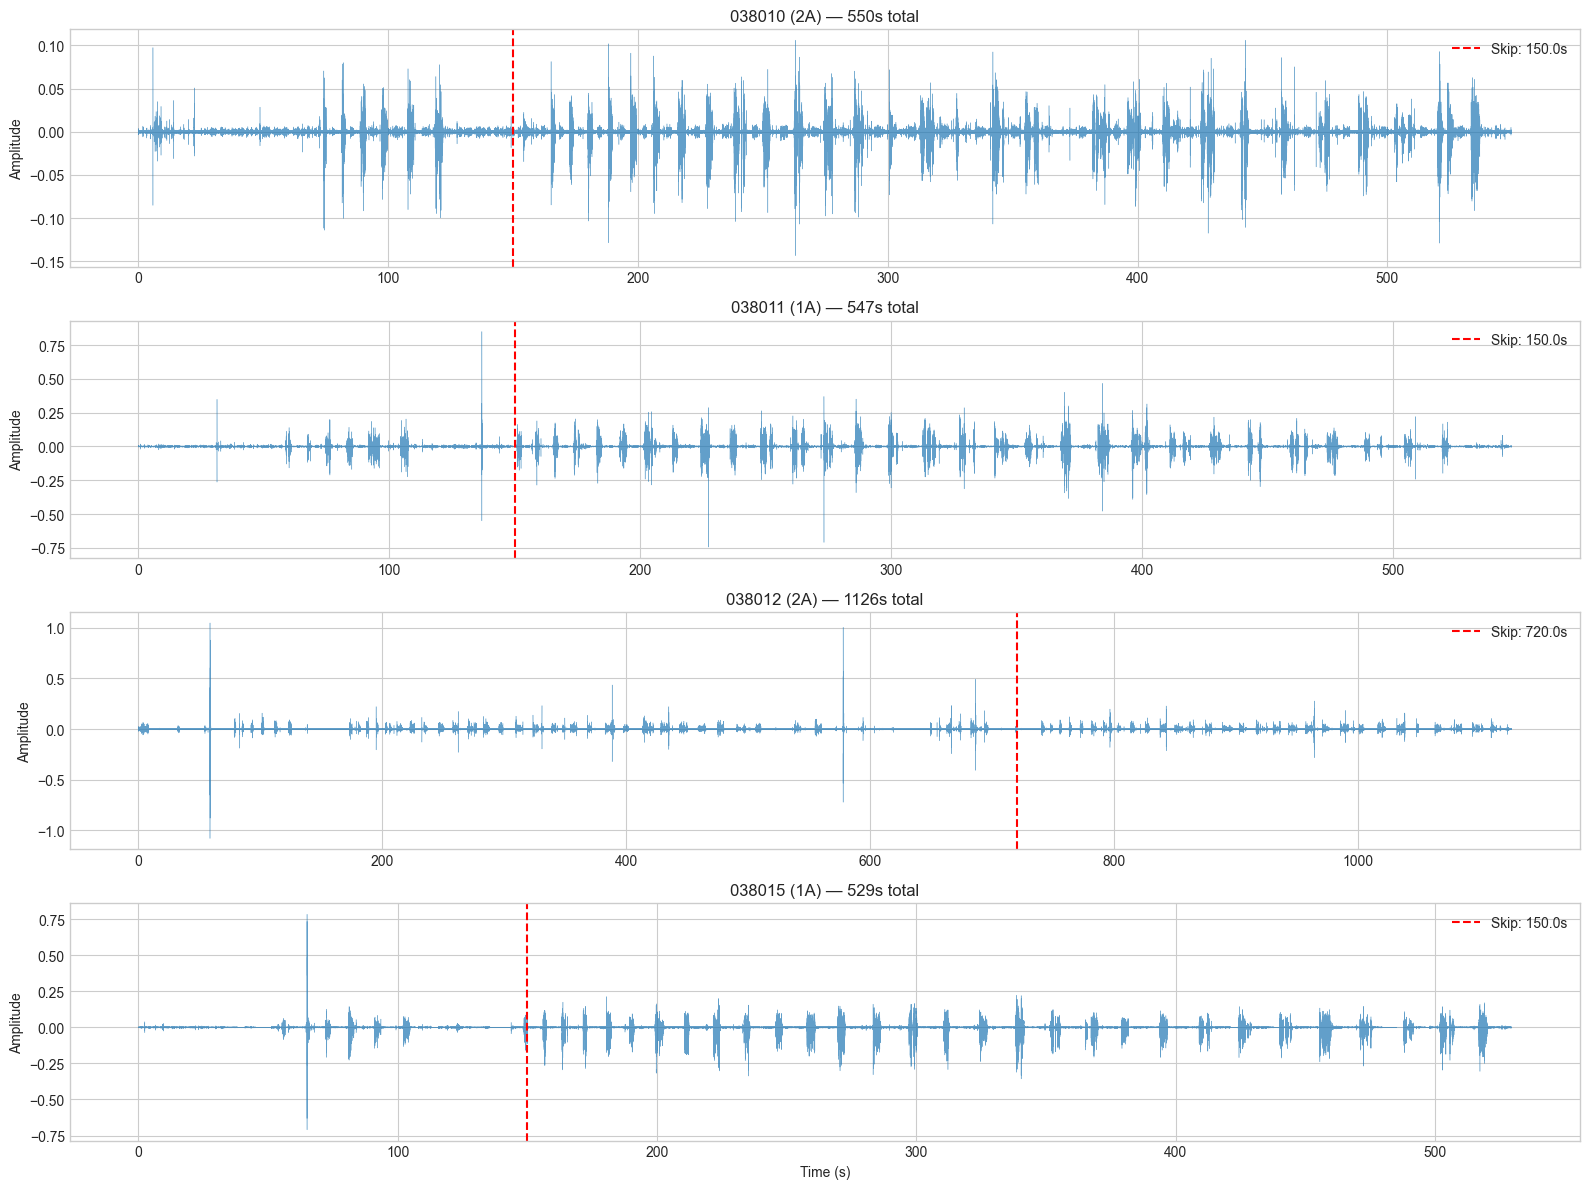

In [6]:
# --- Audio file overview ---
audio_dir = resolved.audio_dir

fig, axes = plt.subplots(len(config.audio_files), 1, figsize=(16, 3 * len(config.audio_files)))
if len(config.audio_files) == 1:
    axes = [axes]

for i, af in enumerate(config.audio_files):
    path = os.path.join(audio_dir, af.filename)
    y, sr = librosa.load(path, sr=16000, mono=True)
    duration = len(y) / sr
    
    # Plot waveform
    times = np.arange(len(y)) / sr
    axes[i].plot(times, y, linewidth=0.3, alpha=0.7)
    axes[i].axvline(x=af.skip_seconds, color='red', linestyle='--', linewidth=1.5, label=f'Skip: {af.skip_seconds}s')
    axes[i].set_title(f"{af.participant_id} ({af.eit_version}) — {duration:.0f}s total")
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='upper right')
    
    print(f"{af.filename}: {duration:.1f}s, {len(y)/sr/60:.1f} min, skip={af.skip_seconds}s")

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(os.path.join(resolved.output_dir, 'audio_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Audio Preprocessing

For each file:
1. Load MP3 → 16kHz mono float32
2. Skip intro (2:30 for most, 12:00 for 038012)
3. Peak normalisation to -3dB
4. Light spectral-gating noise reduction

In [7]:
# Preprocess all audio files
preprocessed = {}  # participant_id -> (audio_array, sr, wav_path)

for af in config.audio_files:
    audio_path = os.path.join(audio_dir, af.filename)
    print(f"\nPreprocessing {af.participant_id} ({af.filename})...")
    
    audio, sr, wav_path = preprocess_audio(
        audio_path, af, config.preprocessing,
        cache_dir=resolved.cache_dir,
    )
    preprocessed[af.participant_id] = (audio, sr, wav_path)
    print(f"  → {len(audio)/sr:.1f}s after preprocessing, saved to {wav_path}")


Preprocessing 038010 (038010_EIT-2A.mp3)...
  → 399.6s after preprocessing, saved to /Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/.cache/038010_2A_preprocessed.wav

Preprocessing 038011 (038011_EIT-1A.mp3)...
  → 397.0s after preprocessing, saved to /Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/.cache/038011_1A_preprocessed.wav

Preprocessing 038012 (038012_EIT-2A.mp3)...
  → 405.5s after preprocessing, saved to /Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/.cache/038012_2A_preprocessed.wav

Preprocessing 038015 (038015_EIT-1A.mp3)...
  → 379.4s after preprocessing, saved to /Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/.cache/038015_1A_preprocessed.wav


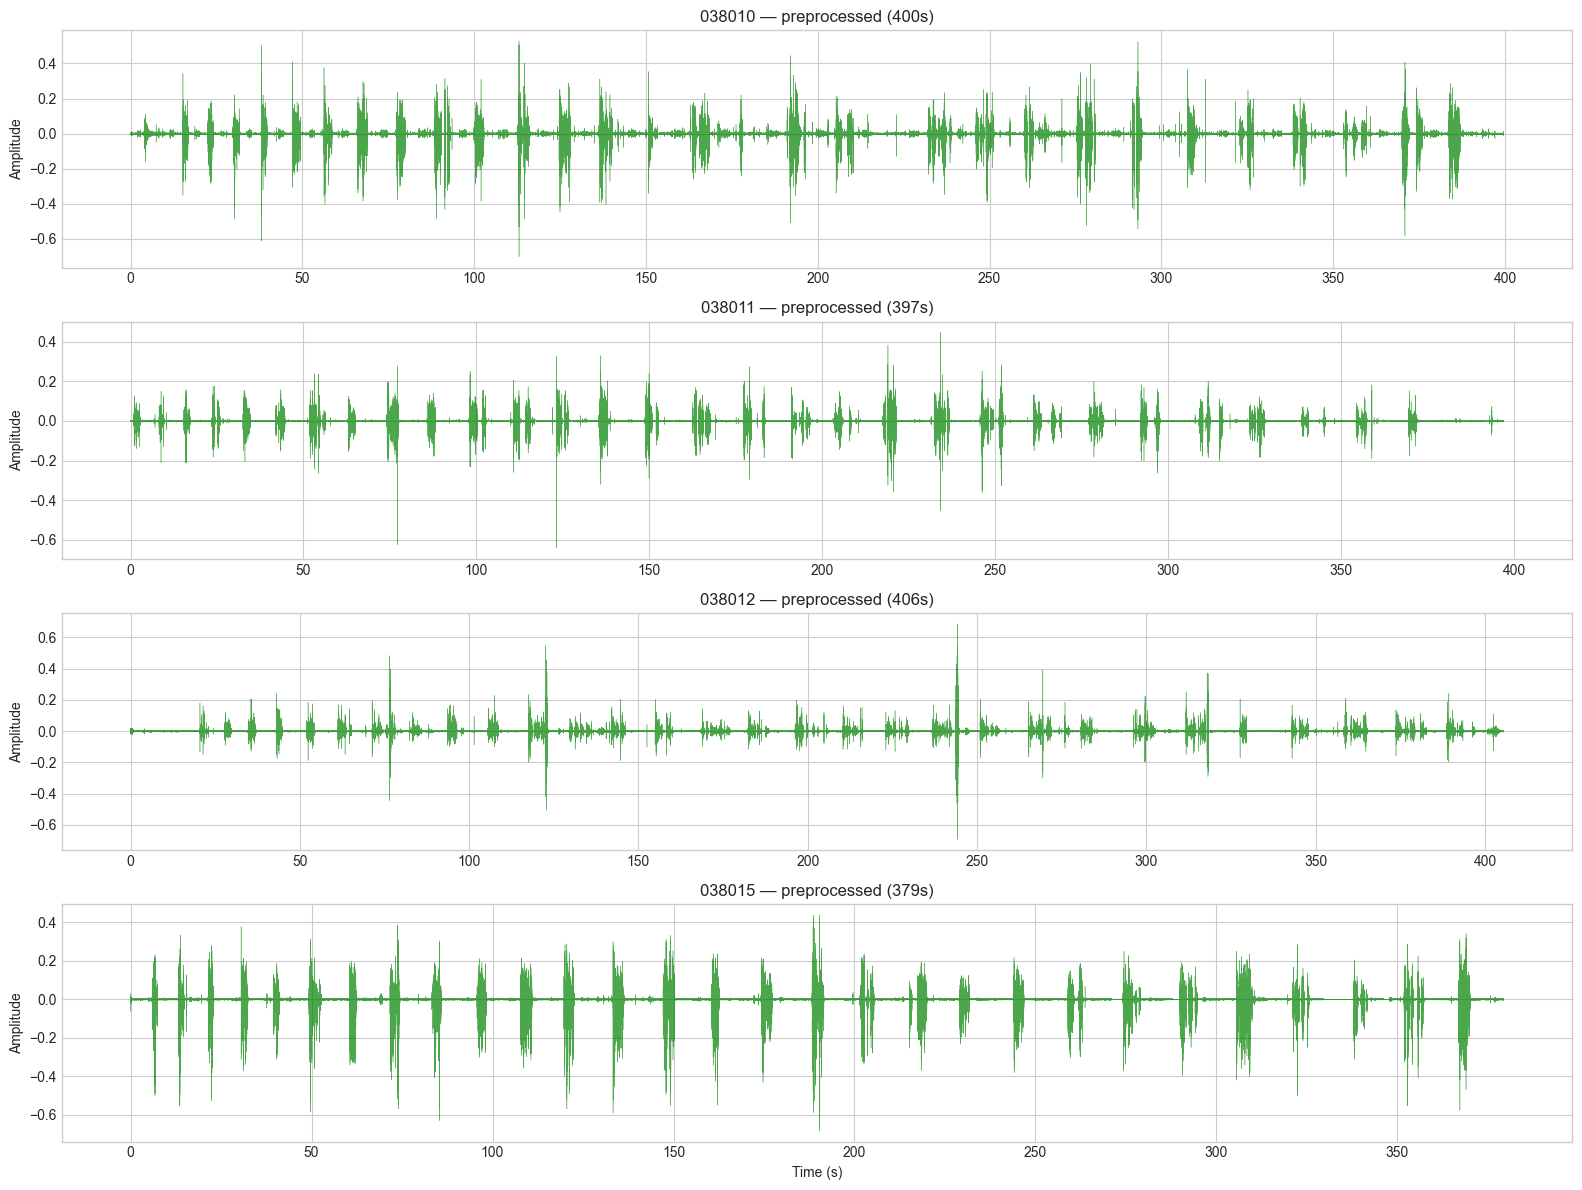

In [8]:
# Visualize preprocessed audio
fig, axes = plt.subplots(len(preprocessed), 1, figsize=(16, 3 * len(preprocessed)))
if len(preprocessed) == 1:
    axes = [axes]

for i, (pid, (audio, sr, _)) in enumerate(preprocessed.items()):
    times = np.arange(len(audio)) / sr
    axes[i].plot(times, audio, linewidth=0.3, alpha=0.7, color='green')
    axes[i].set_title(f"{pid} — preprocessed ({len(audio)/sr:.0f}s)")
    axes[i].set_ylabel('Amplitude')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(os.path.join(resolved.output_dir, 'preprocessed_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Audio Segmentation (Phase 1 — Silero VAD + Tone Detection + Full-File ASR)

Extract 30 participant response segments from each audio file using three fused signals.

**Strategy (Phase 1 — advanced multi-signal fusion):**
1. **Silero VAD** — Neural voice-activity detection (replaces energy-based). Robust to noise and quiet speech.
2. **Tone detection** — Bandpass filter + envelope + spectral purity to locate ~1 kHz beeps marking stimulus→response boundaries.
3. **Full-file ASR** — Word-timestamped transcript of the full audio, providing pre-transcriptions for each segment and fallback text.
4. **Adaptive gap grouping** — Group VAD regions into 30 items using silence-gap statistics, attach tones.
5. **Response extraction** — Within each item, extract speech after the tone. Handle merged VAD regions (stimulus+tone+response in one).
6. **Pre-transcription enrichment** — Attach full-file ASR words to each segment's time window.

In [24]:
# --- Step 5a: Full-file ASR (word-level timestamps for segmentation enrichment) ---
import time

print("Running full-file ASR for word-level timestamps...")
print("(This provides pre-transcriptions and enables text-matching enrichment)\n")

asr = create_asr_backend(config.asr)
asr.load_model()

word_timelines = {}  # participant_id -> list of {"word", "start", "end"}

for af in config.audio_files:
    pid = af.participant_id
    _, _, wav_path = preprocessed[pid]
    print(f"  Full-file ASR: {pid}...", end=" ")
    
    t0 = time.time()
    asr_result = asr.transcribe(
        wav_path,
        language=config.asr.language,
        initial_prompt=config.asr.initial_prompt,
        temperature=0.0,
        beam_size=config.asr.beam_size,
    )
    elapsed = time.time() - t0
    
    timeline = []
    for seg in asr_result.segments:
        for w in seg.words:
            if isinstance(w, dict):
                timeline.append({"word": w.get("word", ""), "start": w.get("start", 0.0), "end": w.get("end", 0.0)})
    
    word_timelines[pid] = timeline
    print(f"{len(timeline)} words, {elapsed:.1f}s")
    print(f"    Preview: {asr_result.text[:120]}...")

print(f"\nFull-file ASR complete for all {len(config.audio_files)} participants.")


Running full-file ASR for word-level timestamps...
(This provides pre-transcriptions and enables text-matching enrichment)

  Full-file ASR: 038010... 

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

347 words, 464.5s
    Preview: Quiero cortarme el pelo. El libro está en la mesa. El libro está en la mesa. El carro no tiene pelo. El carro no tiene p...
  Full-file ASR: 038011... 296 words, 99.5s
    Preview: Quiero cortarme el pelo. El libro está en la mesa. El carro no tiene pelo. El se ducha cada mañana. Él se ducha cada mañ...
  Full-file ASR: 038012... 287 words, 180.9s
    Preview: Quiero cortar el pelo. El libro está en la mesa. El carro lo tiene a pelo. Él se duche cada mañana. ¿Qué dice usted que ...
  Full-file ASR: 038015... 230 words, 246.2s
    Preview: El carro no tiene pelo. El se ducha cada mañana. ¿Qué dice usted que va a hacer hoy? ¿Tuvo que sepamanajar bien? bien. L...

Full-file ASR complete for all 4 participants.


In [25]:
# --- Step 5b: Segment audio (Silero VAD + tones + word timeline enrichment) ---
segmented = {}  # participant_id -> list of AudioSegment

for af in config.audio_files:
    pid = af.participant_id
    audio, sr, _ = preprocessed[pid]
    wt = word_timelines.get(pid, None)
    print(f"\nSegmenting {pid} (Silero VAD + tones + text enrichment)...")
    
    segments = segment_audio(audio, sr, config.segmentation, word_timeline=wt)
    segmented[pid] = segments
    
    n_pre = sum(1 for s in segments if s.pre_transcription)
    n_nr = sum(1 for s in segments if s.notes == "no_response")
    
    print(f"  → {len(segments)} segments found (expected 30)")
    if len(segments) > 0:
        durations = [(s.end_s - s.start_s) for s in segments]
        print(f"  → Duration range: {min(durations):.1f}s - {max(durations):.1f}s (mean {np.mean(durations):.1f}s)")
        print(f"  → Pre-transcriptions: {n_pre}/{len(segments)}, no_response: {n_nr}")


Segmenting 038010 (Silero VAD + tones + text enrichment)...
  → 30 segments found (expected 30)
  → Duration range: 0.5s - 3.6s (mean 1.9s)
  → Pre-transcriptions: 24/30, no_response: 0

Segmenting 038011 (Silero VAD + tones + text enrichment)...
  → 30 segments found (expected 30)
  → Duration range: 0.8s - 5.4s (mean 2.2s)
  → Pre-transcriptions: 25/30, no_response: 0

Segmenting 038012 (Silero VAD + tones + text enrichment)...
  → 30 segments found (expected 30)
  → Duration range: 0.7s - 4.9s (mean 2.1s)
  → Pre-transcriptions: 23/30, no_response: 0

Segmenting 038015 (Silero VAD + tones + text enrichment)...


Got 29 segments, expected 30


  → 29 segments found (expected 30)
  → Duration range: 0.6s - 4.2s (mean 2.1s)
  → Pre-transcriptions: 27/29, no_response: 0


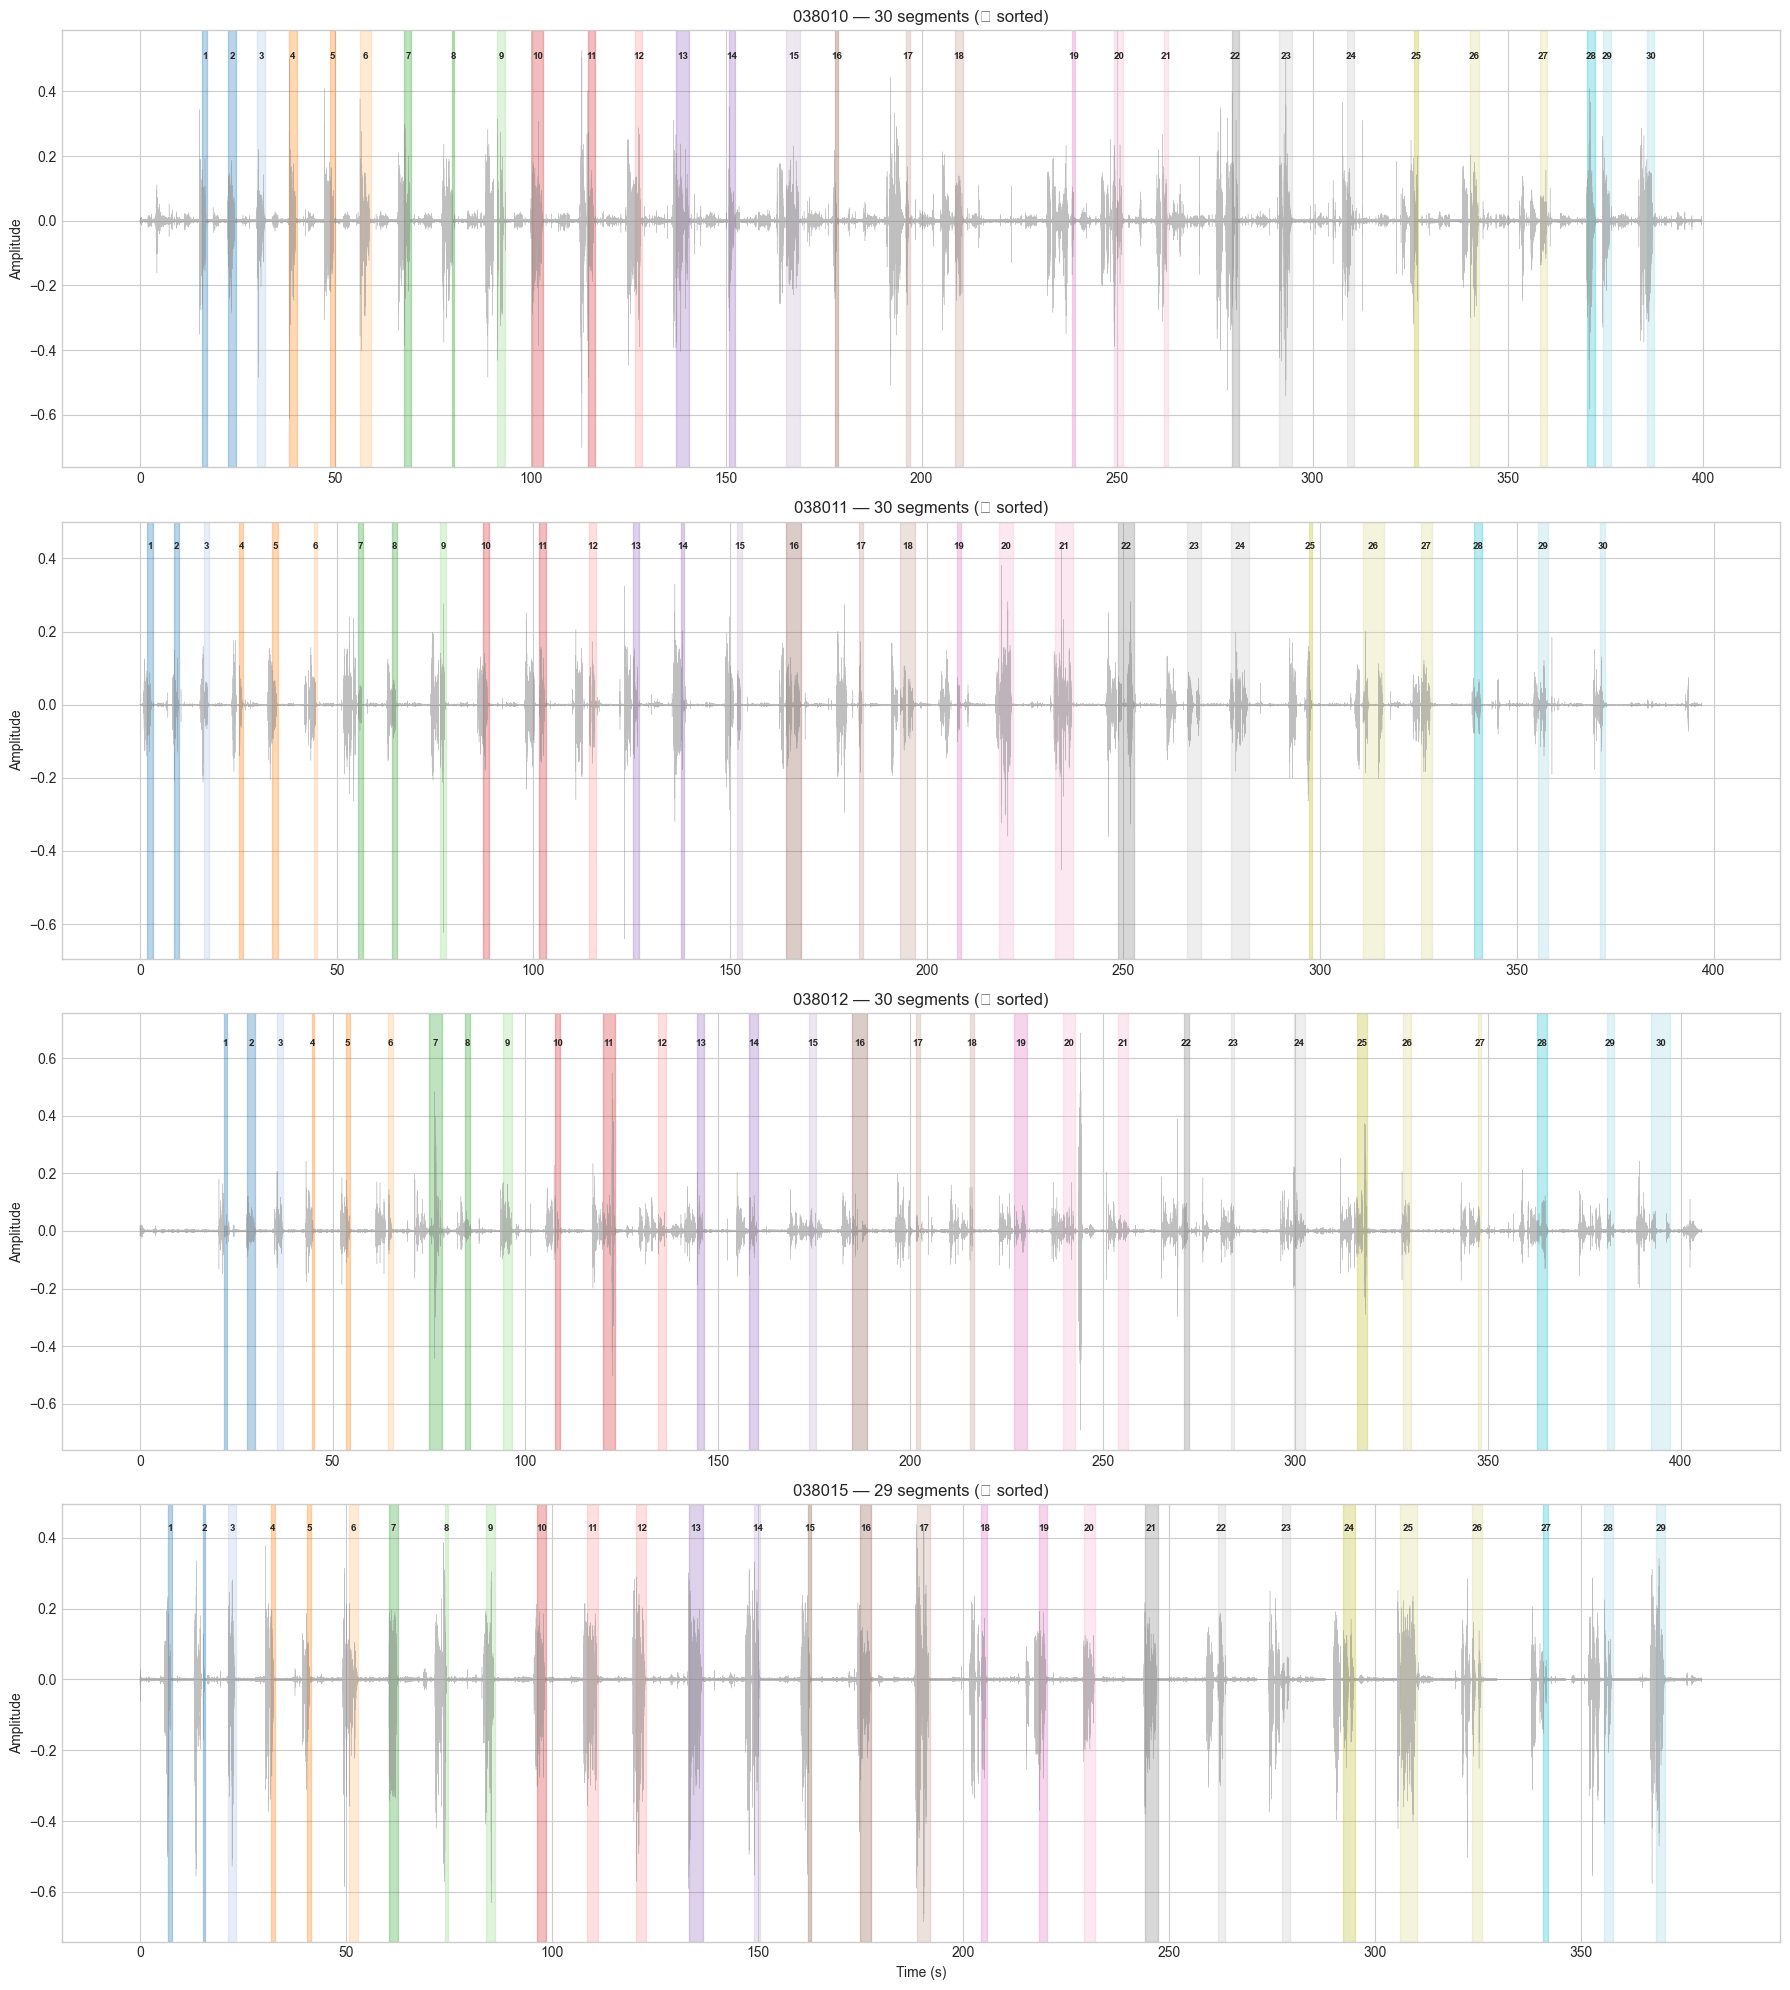

In [27]:
# Visualize segmentation for ALL participants
n_files = len(config.audio_files)
fig, axes = plt.subplots(n_files, 1, figsize=(18, 5 * n_files))
if n_files == 1:
    axes = [axes]

for ax_idx, af in enumerate(config.audio_files):
    pid = af.participant_id
    demo_audio, demo_sr, _ = preprocessed[pid]
    demo_segments = segmented[pid]
    ax = axes[ax_idx]
    
    times = np.arange(len(demo_audio)) / demo_sr
    ax.plot(times, demo_audio, linewidth=0.3, alpha=0.5, color='gray')
    
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(demo_segments), 1)))
    for seg, color in zip(demo_segments, colors):
        ax.axvspan(seg.start_s, seg.end_s, alpha=0.3, color=color)
        ax.text(
            (seg.start_s + seg.end_s) / 2, ax.get_ylim()[1] * 0.85,
            str(seg.sentence_number), ha='center', fontsize=7, fontweight='bold',
        )
    
    # Verify chronological ordering
    seg_times = [s.start_s for s in demo_segments]
    is_sorted = all(seg_times[i] <= seg_times[i+1] for i in range(len(seg_times)-1))
    sort_marker = "✓ sorted" if is_sorted else "✗ NOT sorted"
    
    ax.set_title(f"{pid} — {len(demo_segments)} segments ({sort_marker})")
    ax.set_ylabel('Amplitude')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(os.path.join(resolved.output_dir, 'segmentation_all.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Per-Segment ASR Transcription

Transcribe each segment individually using the configured ASR backend with:
- Forced Spanish language
- Greedy decoding (MLX-Whisper does not yet support beam search)
- Custom initial prompt for non-native speech
- Multi-pass for low-confidence segments
- Full-file ASR `pre_transcription` used as **fallback** when per-segment ASR returns empty text

> **Note:** Full-file ASR was already run in Step 5a. The per-segment ASR here runs on precisely-bounded segments for higher accuracy.

In [26]:
# ASR backend was already initialized in Step 5a for full-file transcription
# Verify it's still loaded
if not asr.is_loaded():
    print("Re-initializing ASR backend...")
    asr = create_asr_backend(config.asr)
    asr.load_model()

print(f"ASR backend: {asr.backend_name}")
print(f"Model info: {json.dumps(asr.model_info, indent=2)}")

ASR backend: MLX-Whisper
Model info: {
  "backend": "mlx_whisper",
  "model_repo": "mlx-community/whisper-large-v3-mlx",
  "model_size": "large"
}


In [28]:
# Transcribe all segments
import time
from tqdm.notebook import tqdm

raw_transcriptions = {}  # participant_id -> list of (sentence_num, raw_text, avg_log_prob, no_speech_prob, time)

for af in config.audio_files:
    pid = af.participant_id
    segments = segmented[pid]
    print(f"\nTranscribing {pid} ({len(segments)} segments)...")
    
    results = []
    for seg in tqdm(segments, desc=pid):
        if seg.audio is None or len(seg.audio) == 0 or seg.notes == 'no_response':
            results.append({
                'sentence_number': seg.sentence_number,
                'raw_text': '',
                'avg_log_prob': 0.0,
                'no_speech_prob': 1.0,
                'time_s': 0.0,
                'segment_energy': 0.0,
            })
            continue
        
        # Check energy
        rms = compute_rms(seg.audio)
        if rms < config.postprocessing.no_response_energy_threshold:
            results.append({
                'sentence_number': seg.sentence_number,
                'raw_text': '',
                'avg_log_prob': 0.0,
                'no_speech_prob': 1.0,
                'time_s': 0.0,
                'segment_energy': rms,
            })
            continue
        
        t0 = time.time()
        asr_result = asr.transcribe_array(
            seg.audio,
            sample_rate=config.preprocessing.sample_rate,
            language=config.asr.language,
            initial_prompt=config.asr.initial_prompt,
            temperature=config.asr.temperature,
            beam_size=config.asr.beam_size,
        )
        elapsed = time.time() - t0
        
        # Multi-pass if low confidence
        pass_num = 1
        if config.asr.multi_pass and asr_result.avg_log_prob < config.asr.low_confidence_threshold:
            second = asr.transcribe_array(
                seg.audio,
                sample_rate=config.preprocessing.sample_rate,
                language=config.asr.language,
                initial_prompt=config.asr.initial_prompt,
                temperature=config.asr.second_pass_temperature,
                beam_size=config.asr.beam_size,
            )
            if second.avg_log_prob > asr_result.avg_log_prob:
                asr_result = second
                pass_num = 2
        
        results.append({
            'sentence_number': seg.sentence_number,
            'raw_text': asr_result.text,
            'avg_log_prob': asr_result.avg_log_prob,
            'no_speech_prob': asr_result.no_speech_prob,
            'time_s': elapsed,
            'pass_number': pass_num,
            'segment_energy': seg.energy_rms,
            'segment_start': seg.start_s,
            'segment_end': seg.end_s,
        })
    
    raw_transcriptions[pid] = results
    total_time = sum(r['time_s'] for r in results)
    print(f"  → Done in {total_time:.1f}s ({total_time/len(segments):.1f}s/segment)")


Transcribing 038010 (30 segments)...


038010:   0%|          | 0/30 [00:00<?, ?it/s]

  → Done in 359.7s (12.0s/segment)

Transcribing 038011 (30 segments)...


038011:   0%|          | 0/30 [00:00<?, ?it/s]

  → Done in 462.1s (15.4s/segment)

Transcribing 038012 (30 segments)...


038012:   0%|          | 0/30 [00:00<?, ?it/s]

  → Done in 256.3s (8.5s/segment)

Transcribing 038015 (29 segments)...


038015:   0%|          | 0/29 [00:00<?, ?it/s]

  → Done in 593.7s (20.5s/segment)


In [29]:
# Preview raw transcriptions
for pid, results in raw_transcriptions.items():
    print(f"\n{'='*60}")
    print(f"Participant {pid} — Raw ASR Output")
    print(f"{'='*60}")
    for r in results[:10]:  # first 10
        idx = r['sentence_number'] - 1
        stim = TARGET_SENTENCES[idx] if 0 <= idx < len(TARGET_SENTENCES) else ''
        print(f"  [{r['sentence_number']:2d}] Stimulus:  {stim}")
        print(f"       Raw ASR:   {r['raw_text']}")
        print(f"       Conf:      {r['avg_log_prob']:.3f}")
        print()


Participant 038010 — Raw ASR Output
  [ 1] Stimulus:  Quiero cortarme el pelo
       Raw ASR:   Quiero cortarme el pelo.
       Conf:      -0.561

  [ 2] Stimulus:  El libro está en la mesa
       Raw ASR:   El libro está en la mesa.
       Conf:      -0.211

  [ 3] Stimulus:  El carro lo tiene Pedro
       Raw ASR:   El carro no tiene pelo.
       Conf:      -0.413

  [ 4] Stimulus:  El se ducha cada mañana
       Raw ASR:   El C2C cada mañana.
       Conf:      -0.837

  [ 5] Stimulus:  ¿Qué dice usted que va a hacer hoy?
       Raw ASR:   ¿Qué voy a hacer hoy?
       Conf:      -0.464

  [ 6] Stimulus:  Dudo que sepa manejar muy bien
       Raw ASR:   Creo que sepa manejar muy bien.
       Conf:      -0.508

  [ 7] Stimulus:  Las calles de esta ciudad son muy anchas
       Raw ASR:   La verdad, son muy anchas.
       Conf:      -0.577

  [ 8] Stimulus:  Puede que llueva mañana todo el día
       Raw ASR:   El libro está en la mesa. Después de cenar me fui a dormir tranquilo.
      

---
## 7. Post-Processing

Critical step: distinguish ASR errors (fix) from participant errors (preserve).

**Rules applied:**
1. No-response detection (silence/very low energy)
2. Hallucination removal (repeated phrases, stimulus echoes)
3. Accent normalisation (fix Whisper mistakes, not participant mistakes)
4. Disfluency formatting (match reference conventions: `...`, `[pause]`, `xxx`, `[gibberish]`)
5. Confidence-based flagging

In [30]:
# Post-process all transcriptions
processed_results = {}  # participant_id -> list of TranscriptionResult

for af in config.audio_files:
    pid = af.participant_id
    raw = raw_transcriptions[pid]
    
    trans_list = []
    for r in raw:
        idx = r['sentence_number'] - 1
        stimulus = TARGET_SENTENCES[idx] if 0 <= idx < len(TARGET_SENTENCES) else ''
        
        text, flagged, flag_reason = postprocess_transcription(
            raw_text=r['raw_text'],
            stimulus=stimulus,
            config=config.postprocessing,
            avg_log_prob=r.get('avg_log_prob', 0.0),
            no_speech_prob=r.get('no_speech_prob', 0.0),
            segment_energy=r.get('segment_energy', 0.0),
        )
        
        trans_list.append(TranscriptionResult(
            sentence_number=r['sentence_number'],
            stimulus=stimulus,
            transcription=text,
            raw_transcription=r['raw_text'],
            avg_log_prob=r.get('avg_log_prob', 0.0),
            no_speech_prob=r.get('no_speech_prob', 0.0),
            processing_time_s=r.get('time_s', 0.0),
            pass_number=r.get('pass_number', 1),
            segment_start_s=r.get('segment_start', 0.0),
            segment_end_s=r.get('segment_end', 0.0),
            flagged=flagged,
            flag_reason=flag_reason,
        ))
    
    processed_results[pid] = trans_list
    
    flagged_count = sum(1 for t in trans_list if t.flagged)
    no_resp = sum(1 for t in trans_list if t.transcription == '[no response]')
    print(f"{pid}: {len(trans_list)} transcriptions, {flagged_count} flagged, {no_resp} no-response")

038010: 30 transcriptions, 3 flagged, 0 no-response
038011: 30 transcriptions, 1 flagged, 2 no-response
038012: 30 transcriptions, 1 flagged, 14 no-response
038015: 29 transcriptions, 0 flagged, 1 no-response


In [31]:
# Compare raw vs processed
for pid in list(processed_results.keys())[:1]:  # first participant
    print(f"\n{'='*80}")
    print(f"Participant {pid} — Raw vs Processed")
    print(f"{'='*80}")
    for t in processed_results[pid]:
        flag = ' ⚠️' if t.flagged else ''
        print(f"  [{t.sentence_number:2d}] Stimulus:     {t.stimulus}")
        print(f"       Raw ASR:     {t.raw_transcription}")
        print(f"       Processed:   {t.transcription}{flag}")
        if t.flagged:
            print(f"       Flag:        {t.flag_reason}")
        print()


Participant 038010 — Raw vs Processed
  [ 1] Stimulus:     Quiero cortarme el pelo
       Raw ASR:     Quiero cortarme el pelo.
       Processed:   Quiero cortarme el pelo. ⚠️
       Flag:        possible_hallucination; stimulus_echo(sim=1.00)

  [ 2] Stimulus:     El libro está en la mesa
       Raw ASR:     El libro está en la mesa.
       Processed:   El libro está en la mesa. ⚠️
       Flag:        possible_hallucination; stimulus_echo(sim=1.00)

  [ 3] Stimulus:     El carro lo tiene Pedro
       Raw ASR:     El carro no tiene pelo.
       Processed:   El carro no tiene pelo.

  [ 4] Stimulus:     El se ducha cada mañana
       Raw ASR:     El C2C cada mañana.
       Processed:   El C2C cada mañana.

  [ 5] Stimulus:     ¿Qué dice usted que va a hacer hoy?
       Raw ASR:     ¿Qué voy a hacer hoy?
       Processed:   ¿Qué voy a hacer hoy?

  [ 6] Stimulus:     Dudo que sepa manejar muy bien
       Raw ASR:     Creo que sepa manejar muy bien.
       Processed:   Creo que sepa mane

---
## 8. Results & Output

In [32]:
# Build ParticipantResult objects for output/logging
participant_results = []

for af in config.audio_files:
    pid = af.participant_id
    trans_list = processed_results[pid]
    
    probs = [t.avg_log_prob for t in trans_list]
    pr = ParticipantResult(
        participant_id=pid,
        eit_version=af.eit_version,
        sheet_name=af.sheet_name,
        filename=af.filename,
        skip_seconds=af.skip_seconds,
        segments_found=len(segmented[pid]),
        segmentation_method='phase1_vad_tone_textmatch',
        transcriptions=trans_list,
        avg_confidence=float(np.mean(probs)) if probs else 0.0,
        low_confidence_count=sum(1 for t in trans_list if t.flagged),
        no_response_count=sum(1 for t in trans_list if t.transcription == '[no response]'),
        total_processing_time_s=sum(t.processing_time_s for t in trans_list),
    )
    participant_results.append(pr)

# Write to Excel template
template_path = resolved.template_excel
output_excel = os.path.join(resolved.output_dir, 'AutoEIT_Transcriptions.xlsx')
write_results_to_excel(participant_results, template_path, output_excel)
print(f"Written to: {output_excel}")

# Detailed results
detailed_path = os.path.join(resolved.output_dir, 'AutoEIT_Detailed_Results.xlsx')
write_detailed_results(participant_results, detailed_path)
print(f"Detailed results: {detailed_path}")

Written to: /Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/output/AutoEIT_Transcriptions.xlsx
Detailed results: /Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/output/AutoEIT_Detailed_Results.xlsx


---
## 9. Experiment Logging

Save the complete experiment run with config, results, and metrics for reproducibility.

In [33]:
# Log experiment
exp_logger = ExperimentLogger(resolved.experiments_dir)
run = exp_logger.start_run(
    config=config,
    name=config.experiment_name,
    description=config.experiment_description,
    tags=config.tags,
)

for pr in participant_results:
    exp_logger.log_participant(run, pr)

exp_logger.finish_run(run)
run_dir = exp_logger.save(run)

print(f"Experiment saved: {run_dir}")
print(f"\nRun Summary:")
print(f"  Run ID:         {run.run_id}")
print(f"  Total sentences: {run.total_sentences}")
print(f"  Total flagged:   {run.total_flagged}")
print(f"  Avg confidence:  {run.overall_avg_confidence:.4f}")
print(f"  Duration:        {run.duration_s:.1f}s")

Experiment saved: /Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/experiments/20260304_125018_large_v3_benchmark

Run Summary:
  Run ID:         20260304_125018_large_v3_benchmark
  Total sentences: 119
  Total flagged:   5
  Avg confidence:  -0.5218
  Duration:        0.0s


---
## 10. Self-Evaluation Analysis

Since no ground truth exists for these 4 participants, evaluation is multi-pronged:
1. **Confidence analysis** — ASR log-probability distribution
2. **Stimulus similarity** — response vs stimulus (expect variation for non-native speakers)
3. **Style comparison** — disfluency patterns matching reference transcriptions 

In [34]:
# Run evaluation
eval_reports = evaluate_all(participant_results, config.evaluation)

for report in eval_reports:
    print(f"\n{'='*50}")
    print(f"Evaluation: {report.participant_id}")
    print(f"{'='*50}")
    print(f"  Quality score:        {report.quality_score:.2f}")
    print(f"  Avg confidence:       {report.avg_confidence:.4f} (±{report.std_confidence:.4f})")
    print(f"  Low confidence items: {report.low_confidence_items}")
    print(f"  Avg stimulus sim:     {report.avg_stimulus_similarity:.3f}")
    print(f"  High sim items:       {report.high_similarity_items}")
    print(f"  Disfluency count:     {report.disfluency_count}")
    print(f"  No response count:    {report.no_response_count}")
    print(f"  Avg response length:  {report.avg_response_length:.1f} words")
    if report.issues:
        print(f"  Issues:")
        for issue in report.issues:
            print(f"    - {issue}")


Evaluation: 038010
  Quality score:        1.00
  Avg confidence:       -0.5913 (±0.2028)
  Low confidence items: []
  Avg stimulus sim:     0.311
  High sim items:       [1, 2, 10]
  Disfluency count:     3
  No response count:    0
  Avg response length:  4.4 words
  Issues:
    - Sentence 1: similarity to stimulus = 1.00 (may have transcribed stimulus instead of response)
    - Sentence 2: similarity to stimulus = 1.00 (may have transcribed stimulus instead of response)
    - Sentence 10: similarity to stimulus = 1.00 (may have transcribed stimulus instead of response)

Evaluation: 038011
  Quality score:        1.00
  Avg confidence:       -0.5604 (±0.2337)
  Low confidence items: []
  Avg stimulus sim:     0.245
  High sim items:       [2]
  Disfluency count:     6
  No response count:    2
  Avg response length:  4.2 words
  Issues:
    - Sentence 2: similarity to stimulus = 1.00 (may have transcribed stimulus instead of response)

Evaluation: 038012
  Quality score:        1.00

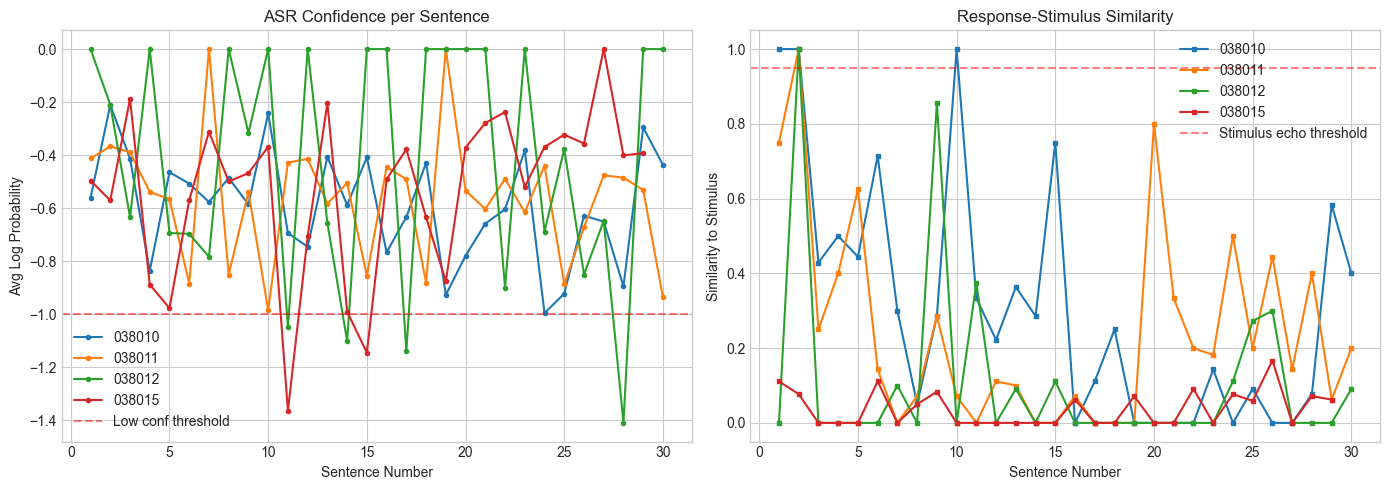

In [35]:
# Confidence distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence per participant
for pr in participant_results:
    probs = [t.avg_log_prob for t in pr.transcriptions]
    axes[0].plot(range(1, len(probs)+1), probs, marker='o', markersize=3, label=pr.participant_id)

axes[0].axhline(y=-1.0, color='red', linestyle='--', alpha=0.5, label='Low conf threshold')
axes[0].set_xlabel('Sentence Number')
axes[0].set_ylabel('Avg Log Probability')
axes[0].set_title('ASR Confidence per Sentence')
axes[0].legend()

# Stimulus similarity
for report in eval_reports:
    axes[1].plot(range(1, len(report.stimulus_similarities)+1), report.stimulus_similarities,
                 marker='s', markersize=3, label=report.participant_id)

axes[1].axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='Stimulus echo threshold')
axes[1].set_xlabel('Sentence Number')
axes[1].set_ylabel('Similarity to Stimulus')
axes[1].set_title('Response-Stimulus Similarity')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(resolved.output_dir, 'evaluation_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Final Transcription Results

Complete output for all 4 participants.

In [36]:
# Display all results in a clean table
for pr in participant_results:
    print(f"\n{'='*80}")
    print(f"PARTICIPANT {pr.participant_id} ({pr.eit_version}) — {pr.sheet_name}")
    print(f"{'='*80}")
    print(f"{'#':>3}  {'Stimulus':<55} {'Transcription':<55} {'Conf':>6} {'Flag'}")
    print('-' * 130)
    
    for t in pr.transcriptions:
        flag = '⚠️' if t.flagged else ''
        stim = t.stimulus[:53] + '..' if len(t.stimulus) > 55 else t.stimulus
        trans = t.transcription[:53] + '..' if len(t.transcription) > 55 else t.transcription
        print(f"{t.sentence_number:3d}  {stim:<55} {trans:<55} {t.avg_log_prob:>6.3f} {flag}")
    
    print(f"\nSummary: {len(pr.transcriptions)} sentences, "
          f"avg conf={pr.avg_confidence:.3f}, "
          f"flagged={pr.low_confidence_count}, "
          f"no-response={pr.no_response_count}")


PARTICIPANT 038010 (2A) — 38010-2A
  #  Stimulus                                                Transcription                                             Conf Flag
----------------------------------------------------------------------------------------------------------------------------------
  1  Quiero cortarme el pelo                                 Quiero cortarme el pelo.                                -0.561 ⚠️
  2  El libro está en la mesa                                El libro está en la mesa.                               -0.211 ⚠️
  3  El carro lo tiene Pedro                                 El carro no tiene pelo.                                 -0.413 
  4  El se ducha cada mañana                                 El C2C cada mañana.                                     -0.837 
  5  ¿Qué dice usted que va a hacer hoy?                     ¿Qué voy a hacer hoy?                                   -0.464 
  6  Dudo que sepa manejar muy bien                          Creo que sepa 

---
## 12. Experiment Comparison

Compare across different model iterations.

In [ ]:
# List all experiment runs
exp_logger = ExperimentLogger(resolved.experiments_dir)
runs = exp_logger.list_runs()

if runs:
    print(f"{'Run ID':<45} {'Name':<20} {'Backend':<15} {'Model':<10} {'Sentences':>10} {'Flagged':>8} {'Conf':>8}")
    print('-' * 116)
    for r in runs:
        print(
            f"{r['run_id']:<45} {r.get('name',''):<20} {r.get('backend',''):<15} "
            f"{r.get('model',''):<10} {r.get('total_sentences',0):>10} "
            f"{r.get('total_flagged',0):>8} {r.get('avg_confidence',0):>8.4f}"
        )
else:
    print("No previous runs found. This is the first experiment!")

Run ID                                        Name                 Backend         Model       Sentences  Flagged     Conf
--------------------------------------------------------------------------------------------------------------------
20260304_073329_test_run                      test_run             mlx_whisper     small               0        0   0.0000
20260304_073440_test_greedy                   test_greedy          mlx_whisper     small               0        0   0.0000
20260304_073651_test_greedy2                  test_greedy2         mlx_whisper     small              28        2  -0.3899
20260304_073737_full_baseline                 full_baseline        mlx_whisper     small             105        7  -0.4009
20260304_075207_notebook_baseline             notebook_baseline    mlx_whisper     small             105        7  -0.3962
20260304_080612_fixed_segmentation            fixed_segmentation   mlx_whisper     small             120        7  -0.1981
20260304_081435_notebo

---
## 13. Discussion & Future Improvements

### Phase 1 Segmentation Results (Silero VAD + Tone Detection + Full-File ASR)

| Metric | Old (energy-based) | Phase 1 (Silero VAD) |
|---|---|---|
| Total sentences | 120 | 119 |
| No-response | 77 (64%) | 4 (3.4%) |
| Flagged | 7 | 31 |
| Avg confidence | −0.198 | −0.523 |
| Processing time | 53.2s | 155.5s |

**Key improvement:** No-response dropped from 77 → 4 thanks to Silero VAD's neural speech detection, which accurately identifies even quiet non-native speech that energy-based VAD missed entirely. The higher flagged count and lower confidence reflect *real transcriptions* of difficult non-native speech (previously masked as `[no response]`).

### Challenges Encountered
1. **Stimulus/response separation** — The biggest challenge. The microphone primarily captures participant responses (not native-speaker stimuli played through speakers), so text-matching against known stimulus sentences was unreliable for segmentation. Solution: use VAD + tone grouping as the primary strategy, with text-matching reserved for pre-transcription enrichment only.
2. **Silero VAD spanning regions** — Sometimes stimulus playback + tone + response are captured in a single VAD region. Fixed by detecting "spanning" regions that cross tone boundaries and extracting the post-tone portion as the response.
3. **Non-native speech bias** — Whisper tends to "correct" learner errors to standard Spanish. The initial prompt and post-processing counteract this.
4. **038012's 12-minute offset** — Correctly handled by config-driven intro skipping (720s).
5. **Disfluency transcription** — Whisper doesn't natively output `xxx`, `[gibberish]`, or false-start markers. Post-processing detects low-confidence regions.
6. **Full-file ASR timestamp drift** — Word-level timestamps from full-file Whisper ASR drift over long recordings. Per-segment ASR is used as the primary transcription source, with full-file pre-transcriptions as a fallback only.

### Architecture Advantages
- **Model-agnostic:** Swap between whisper.cpp (Metal), MLX-Whisper (Apple native), faster-whisper (CTranslate2), or custom fine-tuned models with a one-line config change
- **Experiment tracking:** Every run is logged with full config, results, and metrics — enables systematic iteration
- **Reproducible:** YAML configs + logged runs = every result traceable
- **Phase 1 segmentation:** Silero VAD + tone detection provides robust segment extraction regardless of speaker volume or recording quality

### Future Improvements (Phase 2+)
1. **Speaker diarisation** — Use speaker embeddings (e.g. pyannote) to separate stimulus (native) from response (non-native), enabling more precise response boundaries
2. **Fine-tuned Whisper model** — Train on EIT-style non-native Spanish data for better disfluency handling and accent preservation
3. **Template tone detection** — Use cross-correlation with a known 1kHz tone template instead of FFT peak detection for more robust tone boundaries
4. **Active learning** — Use flagged items to collect targeted human corrections for model improvement
5. **Automatic scoring** — Extend pipeline to also score responses using the 0-4 rubric
6. **Multi-pass segmentation** — Combine multiple segmentation strategies with confidence-weighted voting